In [53]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

In [70]:
def U(P,bias, alpha, beta, tf):
    return (alpha*P**2 +beta*P**4-P*bias/tf)

def dU_dx(P,bias, alpha, beta, tf):
    return 2*alpha*P +4*beta*P**3 - bias/tf

def del_U(bias, alpha, beta, tf):
    P_A = sc.optimize.fsolve(dU_dx,-1,args=(bias, alpha, beta, tf))
    P_C = sc.optimize.fsolve(dU_dx,0,args=(bias, alpha, beta, tf))
    ddFA = 2*alpha + 12*beta*P_A**2
    ddFC = 2*alpha + 12*beta*P_C**2
    return abs(U(P_A, bias, alpha, beta, tf) - U(P_C, bias, alpha, beta, tf))

def gen_noise(t, sd, bw, dt):
    t_coarse = np.arange(0, t, 1/bw)
    coarse_noise = np.random.normal(0, sd, size=len(t_coarse))
    time = np.arange(0, t, dt)
    wgn = np.interp(time, t_coarse, coarse_noise, left=coarse_noise[0], right=coarse_noise[-1])
    return time, wgn

def TDGL(t, Pini, V, alpha, beta, rho, tf): #solve TDGL equation
    P_fit = [Pini]
    dt = t[1] - t[0]
    for i in range(1,len(t)):
        df_dp = 2*alpha*P_fit[i-1] + 4*beta*P_fit[i-1]**3 - V[i]/tf
        P_fit.append(P_fit[i-1] - dt/rho*df_dp)
    return P_fit

def noise_spectral_analysis(noise, fs):
    freq, psd = sc.signal.periodogram(noise, fs, window = "boxcar")
    # mv average
    window_size = 500
    psd_mva = [psd[0]]
    for i in range(1, len(psd)):
        if i < window_size:
            psd_mva.append(np.mean(psd[0:i+1]))
        else:
            psd_mva.append(psd_mva[i-1] + (psd[i] - psd[i - window_size]) / window_size)
    return freq, psd, psd_mva

In [67]:
# parameters
alpha =-5.38e7
beta = 1.04e9
rho = 370
tf = 255e-9
dt = 1e-9
bw = 1e5
sd = 100
t = 1e-2
ens = 20
D = sd**2/(2*bw*rho**2*tf**2)  # diffusion coefficent
print("Dext/DelF =", D/del_U(0, alpha, beta, tf))

Dext/DelF = [8.07262864]


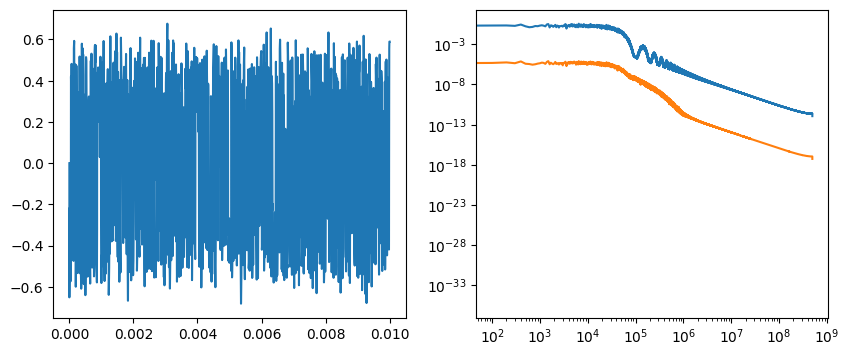

In [73]:
PSD = 0
PSD_P = 0
for e in range(ens):
    time, noise = gen_noise(t, sd, bw, dt)
    P = TDGL(time, 0, noise, alpha, beta, rho, tf)
    freq, psd = sc.signal.periodogram(noise, 1/dt, window = "boxcar")
    freq, psd_P = sc.signal.periodogram(P, 1/dt, window = "boxcar")
    PSD += psd
    PSD_P += psd_P 
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(time, P)
plt.subplot(1,2,2)
plt.loglog(freq, PSD/ens)
plt.loglog(freq, PSD_P/ens)

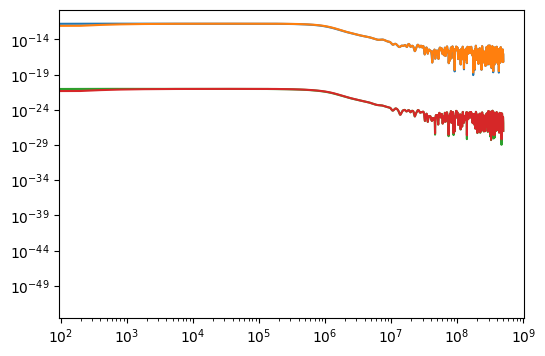

In [74]:
freq, PSD, PSD_mva = noise_spectral_analysis(PSD/ens, 1/dt)
freq, PSD_P, PSD_P_mva = noise_spectral_analysis(PSD_P/ens, 1/dt)

plt.figure(figsize=(6,4))
plt.loglog(freq, PSD)
plt.loglog(freq, PSD_mva)

plt.loglog(freq, PSD_P)
plt.loglog(freq, PSD_P_mva)